In [1]:
import sys
import os
from google.colab import drive

# 1. Association de mon Google Drive au notebook Colab
drive.mount('/content/drive')

# 2. Définition du chemin exact vers mon dossier projet_4
dossier_projet = '/content/drive/MyDrive/Colab Notebooks/projet_5'

# 3. Se déplacer dans ce dossier pour que les fichiers de données (data) soient accessibles directement
os.chdir(dossier_projet)

# 4. Ajouter le dossier au système pour que "import utils" et des donnees fonctionne
sys.path.append(dossier_projet)

print("Dossier actuel :", os.getcwd())
print("Contenu du dossier :", os.listdir())

Mounted at /content/drive
Dossier actuel : /content/drive/MyDrive/Colab Notebooks/projet_5
Contenu du dossier : ['utils.py', 'projet_5.ipynb']


In [2]:
# Installation des dépendances spécifiques au projet
%pip install -q torchvision kagglehub torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.9 MB/s eta 0:00:00


In [3]:
import os
import random

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.transforms import v2 as T
import torchvision.transforms.v2.functional as F
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import kagglehub

from utils import (SPECIES, build_fish_dataframe, collate_fn, compute_map, label_path_for,
                   list_images, plot_boxes, plot_ground_truth_grid, plot_loss_curves,
                   plot_species_counts, read_yolo_boxes)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
# Partie 1 - Les poissons (et leurs boîtes) de Kaggle
# Télécharge le dataset (environ 350 Mo, une seule fois : les exécutions suivantes réutilisent le cache local)
DATASET_DIR = kagglehub.dataset_download("mahmoodyousaf/fish-dataset", output_dir="data")

print("Dataset téléchargé dans :", DATASET_DIR)

Using Colab cache for faster access to the 'fish-dataset' dataset.
Dataset téléchargé dans : /kaggle/input/fish-dataset


13 espèces : AngelFish, BlueTang, ButterflyFish, ClownFish, GoldFish, Gourami, MorishIdol, PlatyFish, RibbonedSweetlips, ThreeStripedDamselfish, YellowCichlid, YellowTang, ZebraFish


,image_path,species,split
0,/kaggle/input/fish-dataset/train/images/001_jp...,ButterflyFish,train
1,/kaggle/input/fish-dataset/train/images/001_jp...,ButterflyFish,train
2,/kaggle/input/fish-dataset/train/images/002_jp...,ButterflyFish,train
3,/kaggle/input/fish-dataset/train/images/002_jp...,ButterflyFish,train
4,/kaggle/input/fish-dataset/train/images/002_jp...,ButterflyFish,train


7750 photos étiquetées au total


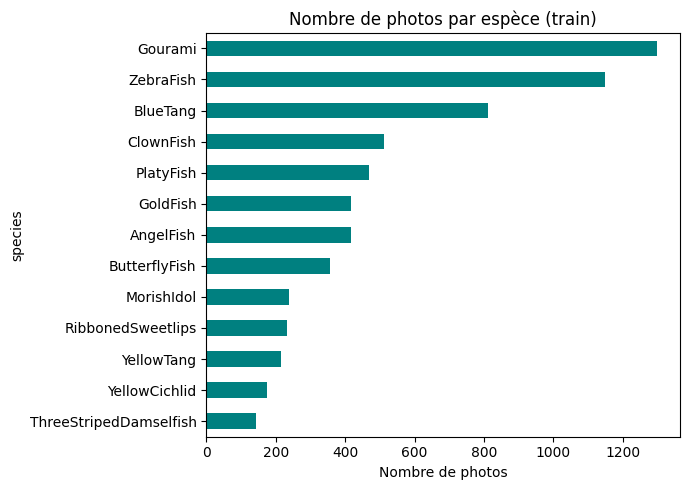

,count
species,
Gourami,1300
ZebraFish,1148
BlueTang,812
ClownFish,512
PlatyFish,468
GoldFish,418
AngelFish,416
ButterflyFish,356
MorishIdol,238


In [5]:
print(f"{len(SPECIES)} espèces : {', '.join(SPECIES)}")

fish_df = build_fish_dataframe(DATASET_DIR)
display(fish_df.head())
print(f"{len(fish_df)} photos étiquetées au total")

plot_species_counts(fish_df, split="train")

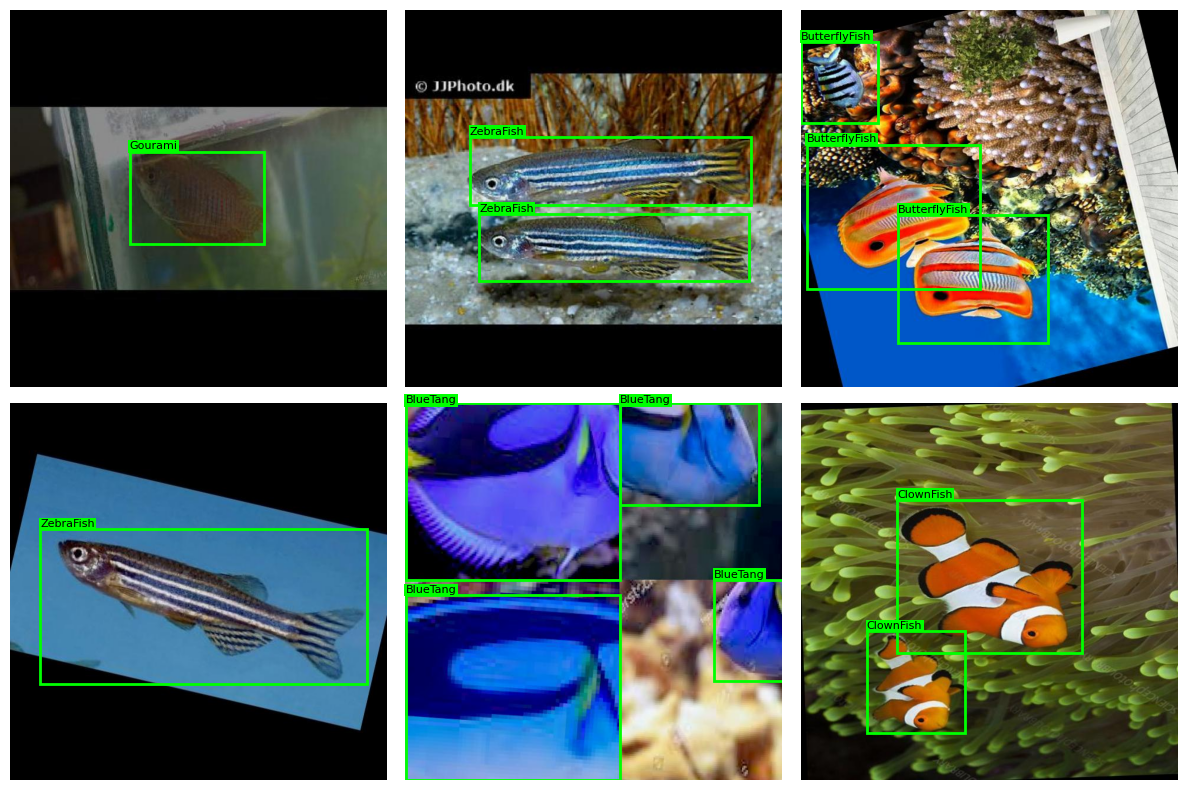

In [6]:
sample_paths = fish_df[fish_df["split"] == "train"]["image_path"].sample(n=6, random_state=SEED).tolist()
plot_ground_truth_grid(sample_paths)

In [7]:
# Partie 2 - Le détecteur pré-entraîné
weights = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT

coco_model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=weights).eval()  # le détecteur pré-entraîné, en évaluation
coco_categories = weights.meta["categories"]                               # les 91 catégories COCO

print(f"Faster R-CNN (MobileNetV3) chargé : {sum(p.numel() for p in coco_model.parameters()):,} paramètres")
print("Catégories COCO contenant 'fish' :", [c for c in coco_categories if "fish" in c.lower()] or "AUCUNE")

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 151MB/s]


Faster R-CNN (MobileNetV3) chargé : 19,386,354 paramètres
Catégories COCO contenant 'fish' : AUCUNE


1 détection(s) : [('bird', 0.98)]
Exercice validé !


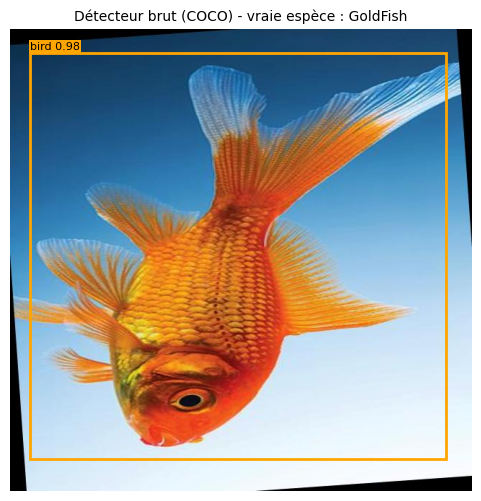

In [23]:
# Étape 1 : faire prédire un détecteur
def predict(model, image_path, names, score_thresh=0.5):
    """
    Run a detection model on an image and keep the detections above score_thresh.

    Arguments:
    model -- a torchvision detection model, in eval mode
    image_path -- path to an image file, of any resolution
    names -- list of category names, indexed by the label indices the model outputs
    score_thresh -- minimum confidence score to keep a detection

    Returns:
    boxes -- list of [x1, y1, x2, y2] pixel boxes
    labels -- list of category names, same order as boxes
    scores -- list of confidence scores, same order as boxes
    """

    image = read_image(image_path)[:3]
    image = F.to_dtype(image, torch.float32, scale=True)
    batch = image.unsqueeze(0)
    with torch.no_grad():
        output = model(batch)[0]

    boxes = output["boxes"]
    labels = output["labels"]
    scores = output["scores"]

    keep = scores > score_thresh
    boxes = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]

    labels = [names[i] for i in labels.tolist()]

    boxes = boxes.tolist()
    scores = scores.tolist()

    return boxes, labels, scores


goldfish_path = os.path.join(DATASET_DIR, "train", "images",
                             "batch_1_34_goldfish_16_jpg.rf.631bf82a6ed6e4ea66637d3ca6b6dae7.jpg")
boxes, labels, scores = predict(coco_model, goldfish_path, coco_categories)
plot_boxes(Image.open(goldfish_path).convert("RGB"), boxes, labels, scores, box_color="orange",
           title="Détecteur brut (COCO) - vraie espèce : GoldFish")

print(f"{len(boxes)} détection(s) : {list(zip(labels, [round(s, 2) for s in scores]))}")
assert isinstance(boxes, list) and isinstance(labels, list) and isinstance(scores, list), \
    "boxes, labels et scores doivent être des listes"
assert len(boxes) == len(labels) == len(scores), "les trois listes doivent avoir la même longueur"
print("Exercice validé !")

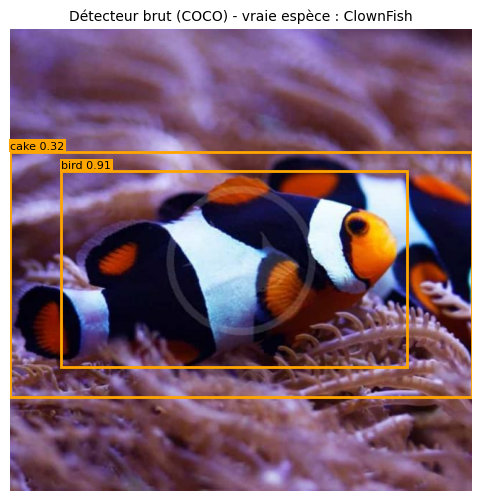

In [24]:
clownfish_path = os.path.join(DATASET_DIR, "train", "images",
                              "CLOWN-PERCULA-CLASSIC-AQUACULTURED-PAIR-Amphiprion-percula_jpg.rf.2d0bece80bf5100491a22972fee01a23.jpg")

boxes, labels, scores = predict(coco_model, clownfish_path, coco_categories, score_thresh=0.3)
plot_boxes(Image.open(clownfish_path).convert("RGB"), boxes, labels, scores, box_color="orange",
           title="Détecteur brut (COCO) - vraie espèce : ClownFish")

In [11]:
# Partie 3 - Servir les données au modèle
basic_transform = T.Compose([T.ToDtype(torch.float32, scale=True)])  # pas d'augmentation pour l'instant


class FishDetectionDataset(Dataset):
    def __init__(self, image_paths, transforms=None):
        self.image_paths = image_paths
        self.transforms = transforms

    def __len__(self):
        """Combien d'échantillons en tout ? Le DataLoader a besoin de le savoir."""
        return len(self.image_paths)

    def __getitem__(self, i):
        """Fabrique l'échantillon numéro i : une image, et tout ce qu'on sait d'elle."""
        image_path = self.image_paths[i]
        image = read_image(image_path)[:3]                                    # la photo, en tensor (3, H, W)
        H, W = image.shape[-2:]
        boxes, class_indices = read_yolo_boxes(label_path_for(image_path), W, H)

        # IDÉE 1 : les boîtes deviennent un tensor de forme (nombre de poissons, 4)
        boxes_t = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)

        # IDÉE 2 : +1 sur chaque espèce. torchvision réserve la classe 0 au "fond"
        # (l'absence d'objet), donc nos 13 espèces occupent les indices 1 à 13.
        # dtype=torch.int64 est obligatoire : sur une photo sans poisson, la liste est
        # vide et torch.tensor([]) fabriquerait des float, que le modèle refuse.
        labels_t = torch.tensor([c + 1 for c in class_indices], dtype=torch.int64)

        # IDÉE 3 : on emballe dans tv_tensors. C'est ce qui permettra plus tard à une
        # rotation ou un miroir de déplacer les boîtes EN MÊME TEMPS que l'image.
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes_t, format="XYXY", canvas_size=(H, W)),
            "labels": labels_t,
        }
        image = tv_tensors.Image(image)

        if self.transforms:
            image, target = self.transforms(image, target)

        return image, target


# Regardons ce que fabrique la recette, sur une photo qu'on connaît déjà
demo_image, demo_target = FishDetectionDataset([clownfish_path], transforms=basic_transform)[0]

print(f"image  : tensor {tuple(demo_image.shape)}, valeurs entre {demo_image.min():.2f} et {demo_image.max():.2f}")
print(f"boîtes : {demo_target['boxes'].shape[0]} poisson(s), coordonnées {demo_target['boxes'].tolist()}")
print(f"labels : {demo_target['labels'].tolist()}  ->  {[SPECIES[i - 1] for i in demo_target['labels'].tolist()]}")

image  : tensor (3, 640, 640), valeurs entre 0.00 et 1.00
boîtes : 1 poisson(s), coordonnées [[7.0, 196.5, 525.0, 458.5]]
labels : [4]  ->  ['ClownFish']


In [12]:
MAX_TRAIN_IMAGES = 1000
MAX_VAL_IMAGES = 300
BATCH_SIZE = 4        # Réduire si manque de mémoire

all_train, all_val = list_images(DATASET_DIR, "train"), list_images(DATASET_DIR, "valid")
train_images = random.sample(all_train, min(MAX_TRAIN_IMAGES, len(all_train)))
val_images = random.sample(all_val, min(MAX_VAL_IMAGES, len(all_val)))

train_loader = DataLoader(FishDetectionDataset(train_images, transforms=basic_transform),
                          batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(FishDetectionDataset(val_images, transforms=basic_transform),
                        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

images, targets = next(iter(train_loader))
print(f"Un batch = {len(images)} images de tailles {[tuple(im.shape[-2:]) for im in images]}")
print(f"            et {[len(t['labels']) for t in targets]} poisson(s) respectivement")
print()
print(f"Entraînement : {len(train_images)} photos, {len(train_loader)} batchs de {BATCH_SIZE}")
print(f"Validation   : {len(val_images)} photos, {len(val_loader)} batchs de {BATCH_SIZE}")

Un batch = 4 images de tailles [(640, 640), (640, 640), (640, 640), (640, 640)]
            et [1, 1, 4, 4] poisson(s) respectivement

Entraînement : 1000 photos, 250 batchs de 4
Validation   : 300 photos, 75 batchs de 4


In [14]:
# Partie 4 - Le fine-tuning
# Étape 1 : adapter le modèle
def build_model(num_classes_with_background):
    """
    Load a pretrained Faster R-CNN (MobileNetV3 backbone) and adapt it to a new number of classes.

    Arguments:
    num_classes_with_background -- number of species to detect, PLUS the background class

    Returns:
    model -- the adapted model, with a frozen backbone and a new box-classification head
    """
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT)

    for p in model.backbone.parameters():
          p.requires_grad = False
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_background)

    return model


model = build_model(len(SPECIES) + 1)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{n_trainable:,} paramètres entraînables sur {sum(p.numel() for p in model.parameters()):,} au total")

assert model.roi_heads.box_predictor.cls_score.out_features == 14, "14 sorties attendues (13 espèces + fond)"
assert all(not p.requires_grad for p in model.backbone.parameters()), "model.backbone devrait être gelé"
print("Exercice validé !")

14,576,785 paramètres entraînables sur 18,991,729 au total
Exercice validé !


In [15]:
# Étape 2 : la boucle d'entraînement
NUM_EPOCHS = 3  # Réduire si trop lent
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=5e-4)

loss_names = ["loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"]
loss_history = {name: [] for name in loss_names}

for epoch in range(NUM_EPOCHS):
    model.train()
    running = {name: 0.0 for name in loss_names}
    n_batches = 0
    for images, targets in train_loader:
        images, targets = list(images), list(targets)

        ### START CODE HERE ###

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### END CODE HERE ###

        for name in loss_names:
            running[name] += loss_dict[name].item()
        n_batches += 1

    for name in loss_names:
        loss_history[name].append(running[name] / n_batches)
    print(f"epoch {epoch + 1}/{NUM_EPOCHS}  loss totale {sum(loss_history[name][-1] for name in loss_names):.3f}")

assert sum(loss_history[name][-1] for name in loss_names) < sum(loss_history[name][0] for name in loss_names), \
    "La loss totale devrait diminuer entre la première et la dernière epoch"
print("Exercice validé !")


epoch 1/3  loss totale 1.236
epoch 2/3  loss totale 0.912
epoch 3/3  loss totale 0.761
Exercice validé !


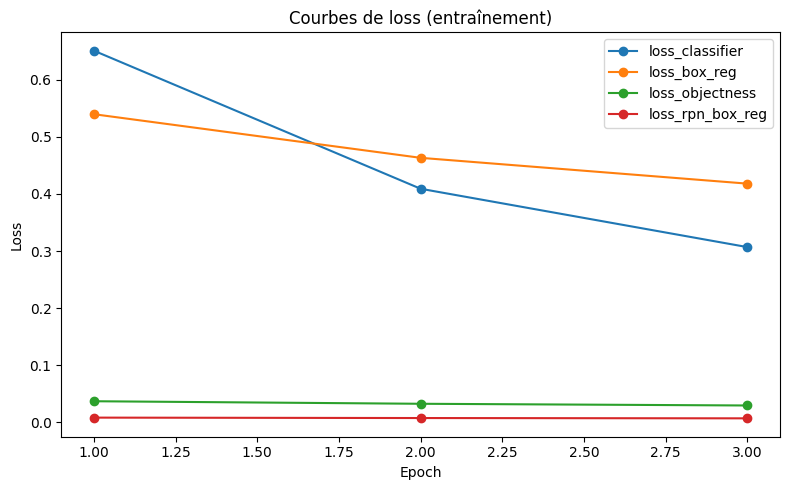

In [16]:
plot_loss_curves(loss_history, NUM_EPOCHS)

1 détection(s) : [('ClownFish', 0.99)]
Exercice validé !


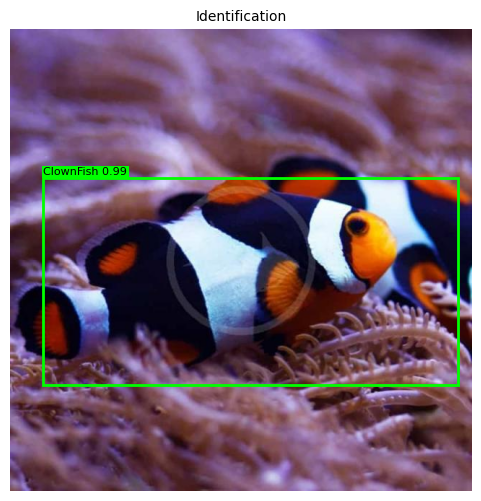

In [25]:
# Partie 5 - Le détecteur fine-tuné à l'oeuvre
model.eval()


def identifier_et_encadrer_poissons(image_path, score_thresh=0.5):
    """
    Detect and identify every fish in a photo, using the fine-tuned model.

    Arguments:
    image_path -- path to an image file, of any resolution
    score_thresh -- minimum confidence score to keep a detection

    Returns:
    boxes -- list of [x1, y1, x2, y2] pixel boxes
    labels -- list of species names, same order as boxes
    scores -- list of confidence scores, same order as boxes
    """

    ### START CODE HERE ###

    names = ["fond"] + SPECIES
    model.eval()
    boxes, labels, scores = predict(model, image_path, names, score_thresh)

    ### END CODE HERE ###

    return boxes, labels, scores


boxes, labels, scores = identifier_et_encadrer_poissons(clownfish_path)
plot_boxes(Image.open(clownfish_path).convert("RGB"), boxes, labels, scores, title="Identification")

print(f"{len(boxes)} détection(s) : {list(zip(labels, [round(s, 2) for s in scores]))}")
assert all(label in SPECIES for label in labels), \
    f"Toutes les étiquettes doivent être des espèces (attention au décalage du fond), tu obtiens {labels}"
print("Exercice validé !")
